##**Predicting Yahoo Daily Adjusted Closing Rate**

##1. **Introduction**
The case study follows David, a financial analyst, and his client Janice. Despite positive market trends, Janice experienced a significant decline in her investment returns. Upon investigation, David discovered that the issue wasn't the market itself, but a massive forecast error in the Yahoo stock within Janice's portfolio. Since Yahoo shares represented a large portion of her investments, the inaccurate prediction led to a major financial mismatch. David now needs to use advanced analytics to find a more reliable way to predict stock prices.

##2. **Problem Statement**

The core challenge is to identify the most effective modeling technique to minimize residual errors in stock forecasting. David must address two specific questions:

**Methodology Selection**: Should he use standard Linear Regression (which treats variables independently) or Time Series Analysis (where time is the continuous exploratory variable)?

**Predictive Accuracy**: How can he model the Adjusted Closing Rate of Yahoo stock to ensure future forecasts align with actual market performance?

##**Feature Name	And Discription**
**Date**

	Date of the given day of trading (The time index).
**Year**

	Year of the given day of trading (Extracted for annual trends).
**Month**

	Month of the given day of trading (Extracted for seasonality).
**Day**

Day of the month of the given day of trading.
**D**
  Floating point representation of the day (Used for mathematical trend modeling).

**Open**

  The price at which the stock first traded when the exchange opened.

**Close**

The final price at which a stock traded during the regular trading session.
**High**

The highest price at which a stock traded during the day.
**Low**

	The lowest price at which a stock traded during the day.
**Volume**
  The total number of shares that were traded during the day.
**adjusted_close**

Target Variable: The closing price that accounts for all corporate actions (dividends/splits).

In [ ]:
# Installing yfinance because the old 'matplotlib.finance' is no longer available
!pip install yfinance -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf # Modern way to get stock data
from datetime import datetime
from matplotlib.pylab import rcParams
from statsmodels.tsa.stattools import adfuller, acf, pacf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import explained_variance_score

# Important for Time Series modeling
from statsmodels.tsa.arima.model import ARIMA

# Plot settings
%matplotlib inline
rcParams['figure.figsize'] = 15, 6

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


##**Feature Exploration & Data Splitting**
1.**Loading and Splitting Data**

[*********************100%***********************]  1 of 1 completed


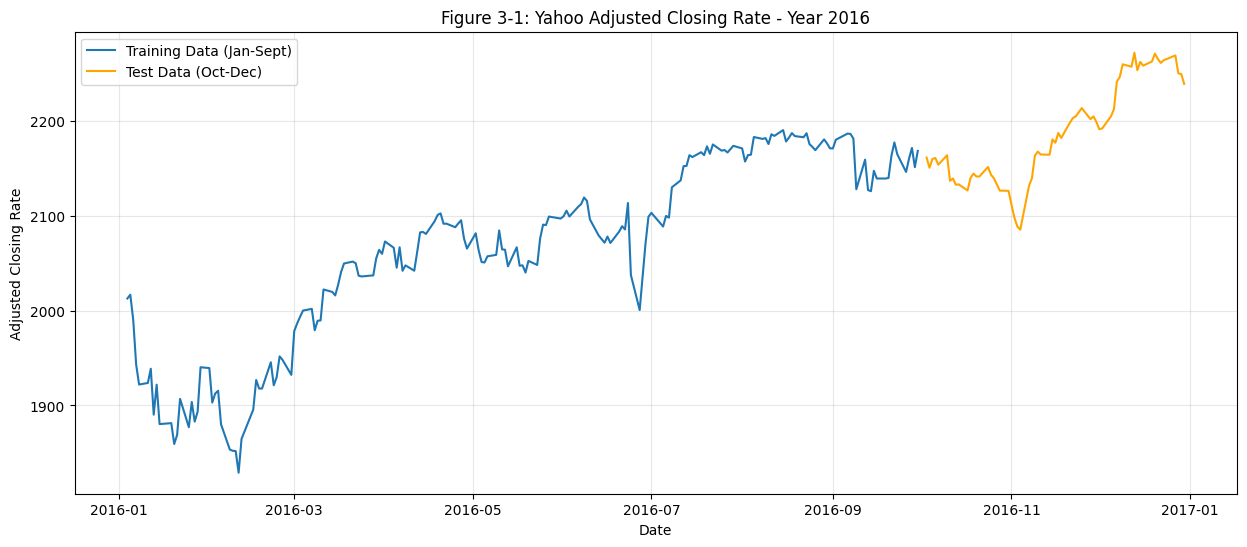

✅ Data loaded and plotted successfully!


In [ ]:
# Updated Listing 3-2 & 3-3 for Google Colab (Python 3.12)
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. Fetching the Data
# We add 'auto_adjust=False' to keep 'Adj Close' and 'Close' separate
# We use 'actions=True' to ensure we get the adjustment data David needs
ticker = "^GSPC"
df_raw = yf.download(ticker, start="2016-01-01", end="2016-12-31", auto_adjust=False)

# 2. Fix for the KeyError: We access the column directly from the 'Adj Close' level
# In the new yfinance, the columns are grouped by the Ticker name
data = pd.DataFrame({'Close_Adj': df_raw['Adj Close'].values.flatten()}, index=df_raw.index)

# 3. Setting the threshold and splitting (Just like David did)
date_thresh = pd.to_datetime('2016-10-01')
data_train = data[data.index < date_thresh]
data_test = data[data.index >= date_thresh]

# 4. Plotting Figure 3-1
plt.figure(figsize=(15, 6))
plt.plot(data_train.index, data_train['Close_Adj'], label='Training Data (Jan-Sept)')
plt.plot(data_test.index, data_test['Close_Adj'], label='Test Data (Oct-Dec)', color='orange')
plt.xlabel('Date')
plt.ylabel('Adjusted Closing Rate')
plt.title('Figure 3-1: Yahoo Adjusted Closing Rate - Year 2016')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("✅ Data loaded and plotted successfully!")

candle plot

##**The Concept of Stationarity**
In his meeting with Maria, David learns that most Time Series models (like ARIMA) assume the data is Stationary. If a series is not stationary, the model's predictions will be unreliable.

1. **What is a Stationary Time Series?**

For a time series to be stationary, it must satisfy four key properties:

**No Trend**: The series should not be moving consistently up or down.

**Constant Mean**: The average value should remain the same over time.

**Constant Variance**: The spread (volatility) of the data should not change.

**No Autocorrelation**: The current value should not be overly dependent on a specific past pattern (lag).

🔍 **Method 1**: **Exploratory Data Analysis (Rolling Statistics)**

Before using complex math, Maria suggests a visual check using Rolling Mean and Rolling Variance.

**Example**: If you have a window of 5 days, the "Rolling Mean" is the average of those 5 days. As you move to the next day, you drop the oldest value and add the newest. If this average line stays flat, the data is likely stationary.

##🧪 **Method 2: The Dickey-Fuller Test**
While the visual test is good, David wants a "Statistical Proof.

" This leads him to the Augmented Dickey-Fuller (ADF) Test.Null Hypothesis ($H_0$): The series is non-stationary.P-value < 0.05: If the p-value is low, we reject the null hypothesis and say the data is stationary.

**The Stationarity Test (ADF Test)**

In this step, David writes a function that combines the Visual (Rolling Statistics) and Statistical (Dickey-Fuller) methods.

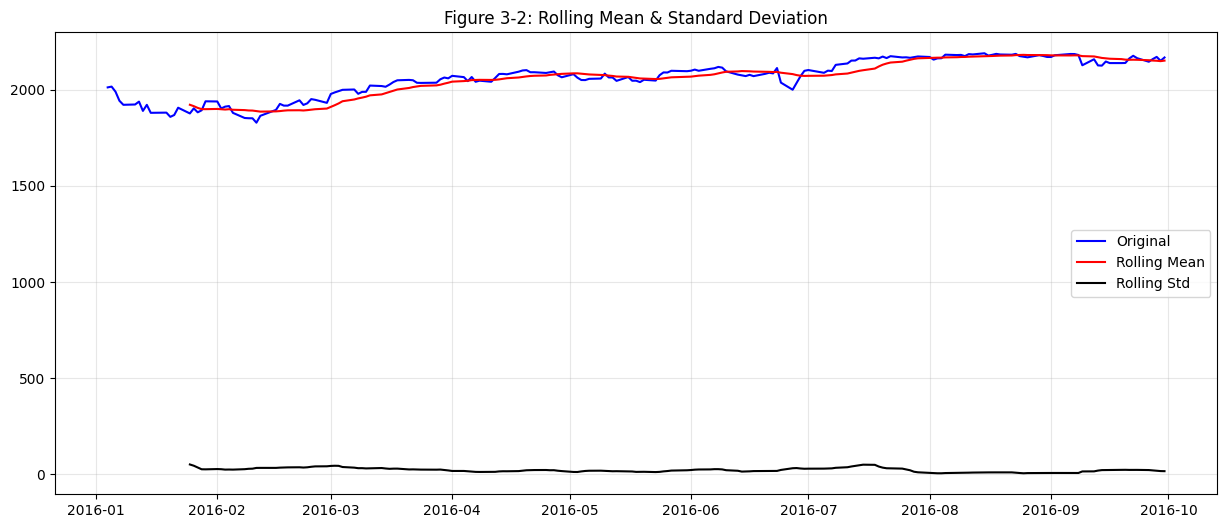

--- Results of Dickey-Fuller Test ---
Test Statistic                  -1.114302
p-value                          0.709335
#Lags Used                       0.000000
Number of Observations Used    188.000000
Critical Value (1%)             -3.465620
Critical Value (5%)             -2.877040
Critical Value (10%)            -2.575032
dtype: float64


In [ ]:
def evaluate_stationarity(timeseries, t=30):
    # 1. Calculating rolling statistics
    rolmean = timeseries.rolling(window=t).mean()
    rolstd = timeseries.rolling(window=t).std()

    # 2. Plotting rolling statistics
    plt.figure(figsize=(15, 6))
    plt.plot(timeseries, color='blue', label='Original')
    plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.plot(rolstd, color='black', label='Rolling Std') # Fixed the nesting error here

    plt.legend(loc='best')
    plt.title('Figure 3-2: Rolling Mean & Standard Deviation')
    plt.grid(True, alpha=0.3)
    plt.show()

    # 3. Performing Dickey-Fuller test:
    print('--- Results of Dickey-Fuller Test ---')
    # adfuller requires data without missing values (NaN),
    # so we drop them just for the calculation
    dftest = adfuller(timeseries.dropna(), autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])

    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value

    print(dfoutput)

# Listing 3-5: Using the method (David used a 15-day window)
evaluate_stationarity(data_train['Close_Adj'], 15)

**Looking at the plot above:**

The **Red Line** (Rolling Mean) is moving upwards. This means the mean is not constant.

The **Black Line** (Rolling Std) might look flat-ish but has small fluctuations.

**Verdict**: Because the Mean is increasing (due to the upward trend), the Yahoo stock data is Non-Stationary.

##**Log Transformation & Zoomed Visualization**
 we will apply the log transformation and then use David’s "Zoom" technique to see why the visual test can sometimes be deceiving.

Testing Log Transformed Data:


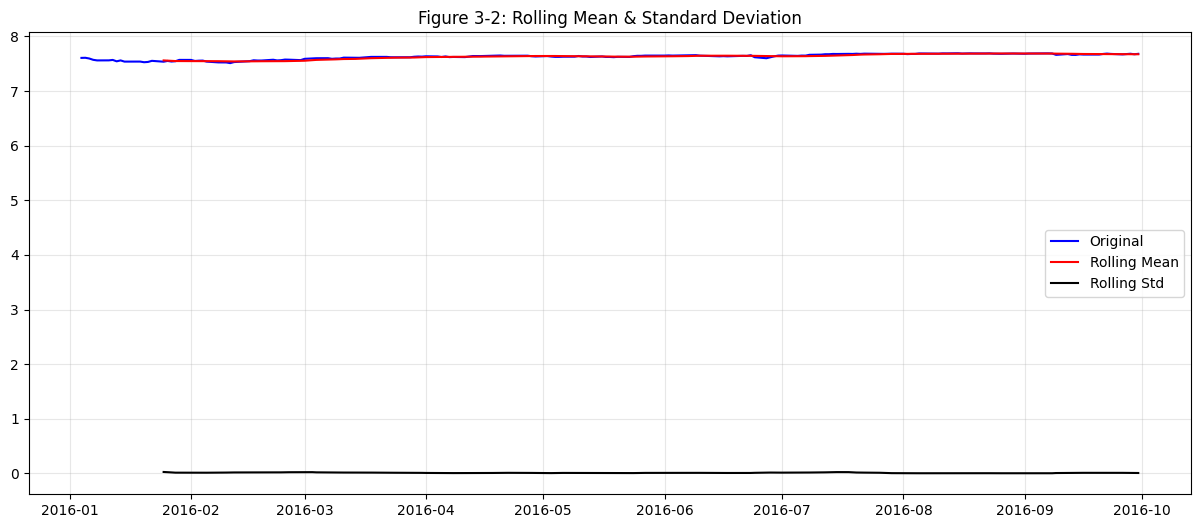

--- Results of Dickey-Fuller Test ---
Test Statistic                  -1.136109
p-value                          0.700460
#Lags Used                       0.000000
Number of Observations Used    188.000000
Critical Value (1%)             -3.465620
Critical Value (5%)             -2.877040
Critical Value (10%)            -2.575032
dtype: float64


In [ ]:
# Applying Log Transformation
data_log = np.log(data_train['Close_Adj'])

# Testing stationarity on the log-transformed data
print("Testing Log Transformed Data:")
evaluate_stationarity(data_log, 15)

**Zooming into the Rolling Mean**
David noticed that in the first graph, the lines looked flat. But the Dickey-Fuller test said it was still non-stationary. To see the truth, he "zooms in" by limiting the Y-axis.

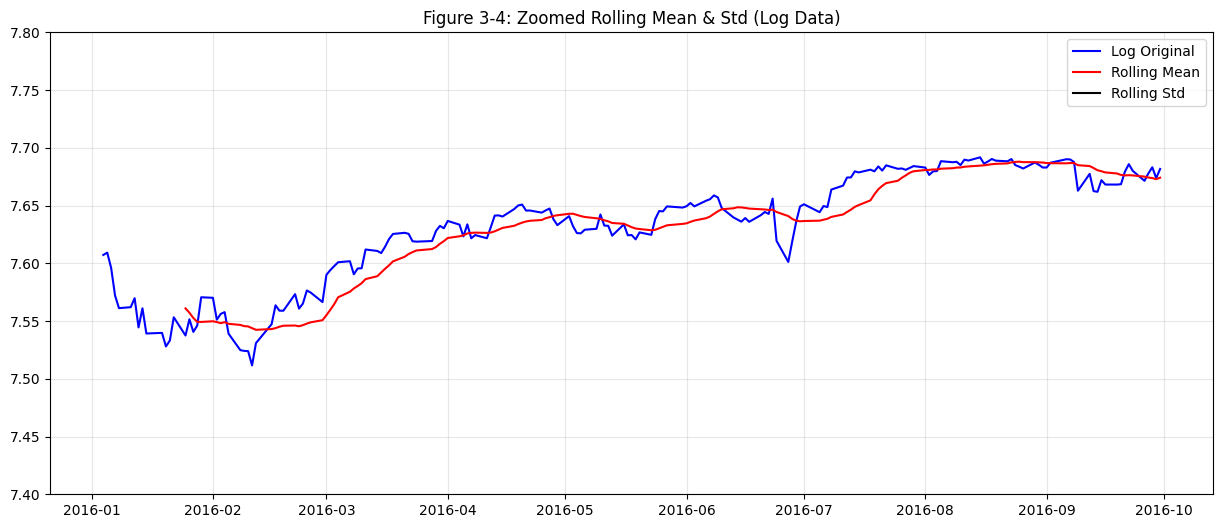

In [ ]:
# Determining rolling statistics for log data
rolmean_log = data_log.rolling(window=15).mean()
rolstd_log = data_log.rolling(window=15).std()

# Plotting with a Zoomed Y-Axis (Figure 3-4)
plt.figure(figsize=(15, 6))
plt.plot(data_log, color='blue', label='Log Original')
plt.plot(rolmean_log, color='red', label='Rolling Mean')
plt.plot(rolstd_log, color='black', label='Rolling Std')

plt.ylim([7.4, 7.8]) # Zooming in to see the variation
plt.legend(loc='best')
plt.title('Figure 3-4: Zoomed Rolling Mean & Std (Log Data)')
plt.grid(True, alpha=0.3)
plt.show()

David finally finds a way to make the data Stationary! He realizes that simple transformations (Log, Square Root) aren't enough because they don't remove the "Trend." He has to mathematically subtract the trend from the data.

##**Trying Different Transformations**
David first tries Square Root and Cube transformations, but they fail the Dickey-Fuller test.

--- Testing Square Root Transformation ---


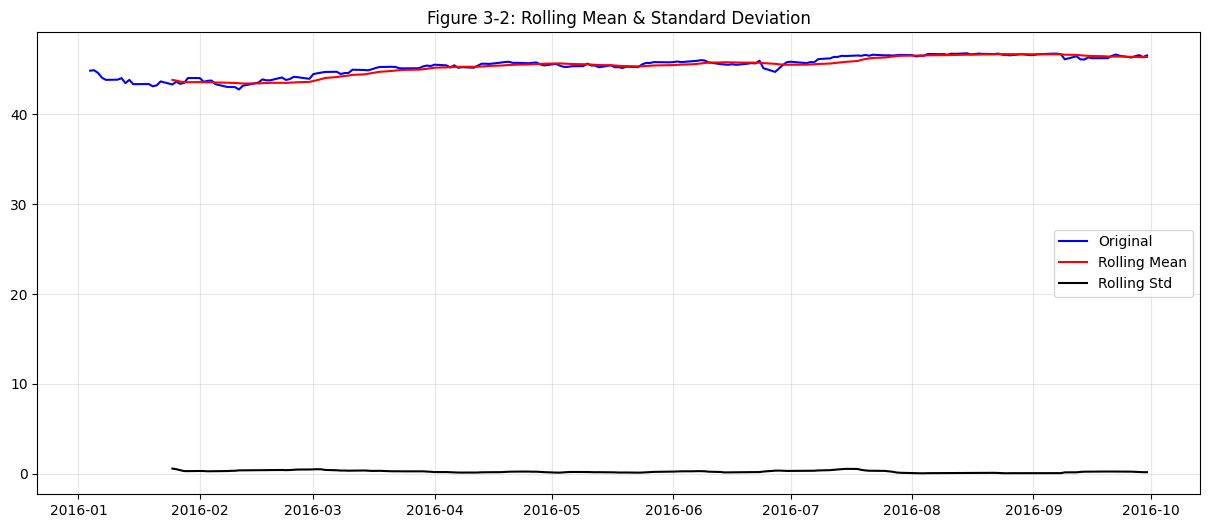

--- Results of Dickey-Fuller Test ---
Test Statistic                  -1.124704
p-value                          0.705121
#Lags Used                       0.000000
Number of Observations Used    188.000000
Critical Value (1%)             -3.465620
Critical Value (5%)             -2.877040
Critical Value (10%)            -2.575032
dtype: float64

--- Testing Cube Transformation ---


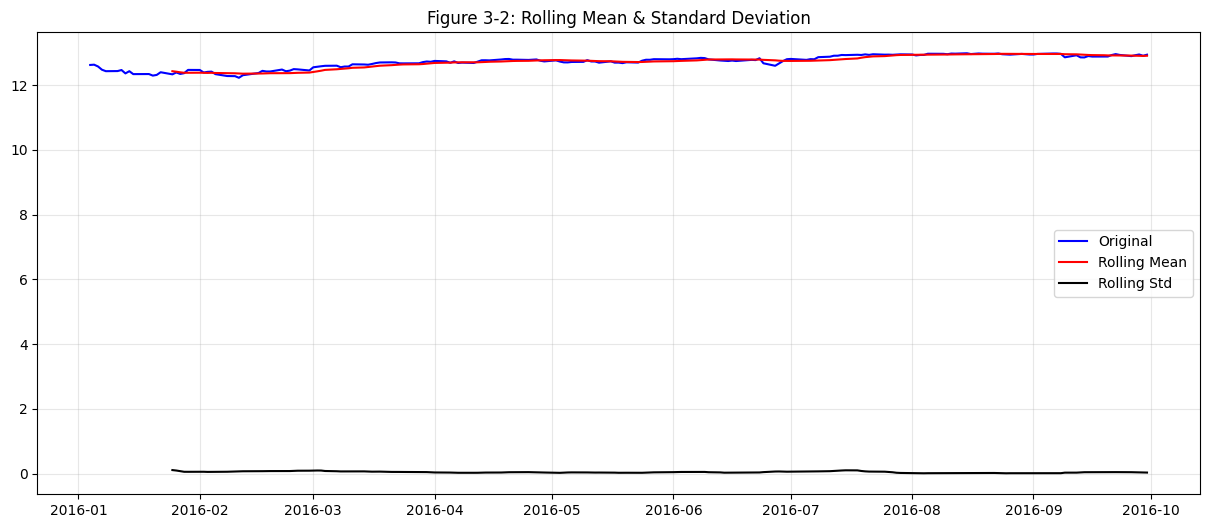

--- Results of Dickey-Fuller Test ---
Test Statistic                  -1.128394
p-value                          0.703617
#Lags Used                       0.000000
Number of Observations Used    188.000000
Critical Value (1%)             -3.465620
Critical Value (5%)             -2.877040
Critical Value (10%)            -2.575032
dtype: float64


In [ ]:
# Square Root Transformation
print("--- Testing Square Root Transformation ---")
data_sqrt = np.sqrt(data_train['Close_Adj'])
evaluate_stationarity(data_sqrt, 15)

# Exercise: Cube Transformation
print("\n--- Testing Cube Transformation ---")
data_cube = np.power(data_train['Close_Adj'], 1/3)
evaluate_stationarity(data_cube, 15)

##**Exponentially Weighted Moving Average (EWMA)**
Unlike a simple moving average, EWMA gives more importance to recent prices. David thinks this might be better because stock markets change fast, and today's price is more relevant than the price from two weeks ago.

--- Results for EWMA Removed Data ---


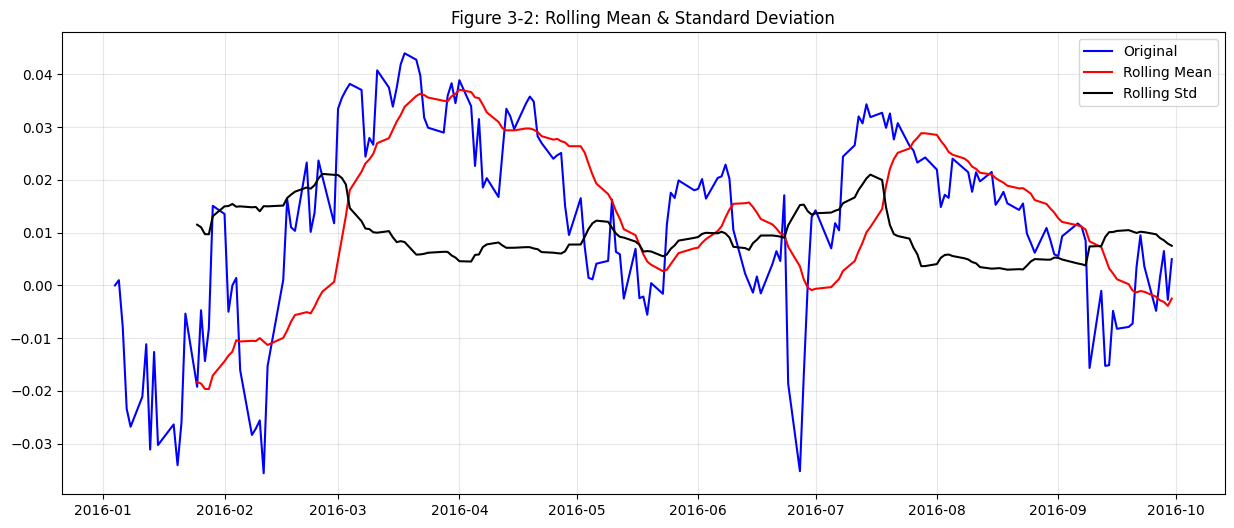

--- Results of Dickey-Fuller Test ---
Test Statistic                  -3.273472
p-value                          0.016107
#Lags Used                       0.000000
Number of Observations Used    188.000000
Critical Value (1%)             -3.465620
Critical Value (5%)             -2.877040
Critical Value (10%)            -2.575032
dtype: float64


In [ ]:
# Modern way to calculate EWMA in Python 3
expweighted_avg = data_log.ewm(halflife=15).mean()
data_log_ewma_diff = data_log - expweighted_avg

print("--- Results for EWMA Removed Data ---")
evaluate_stationarity(data_log_ewma_diff, 15)

**David’s Observation**: The ADF test passed (p-value 0.016), but the graph (Figure 3-8) still looked a bit "wavy." It wasn't as clean as he hoped.

**First-Order Differencing** (The Best Result)Differencing is a simple yet brilliant idea: Instead of looking at the price, look at the change in price from yesterday to today ($Value_t - Value_{t-1}$). This removes both trend and seasonality.

--- Results for First-Order Differencing ---


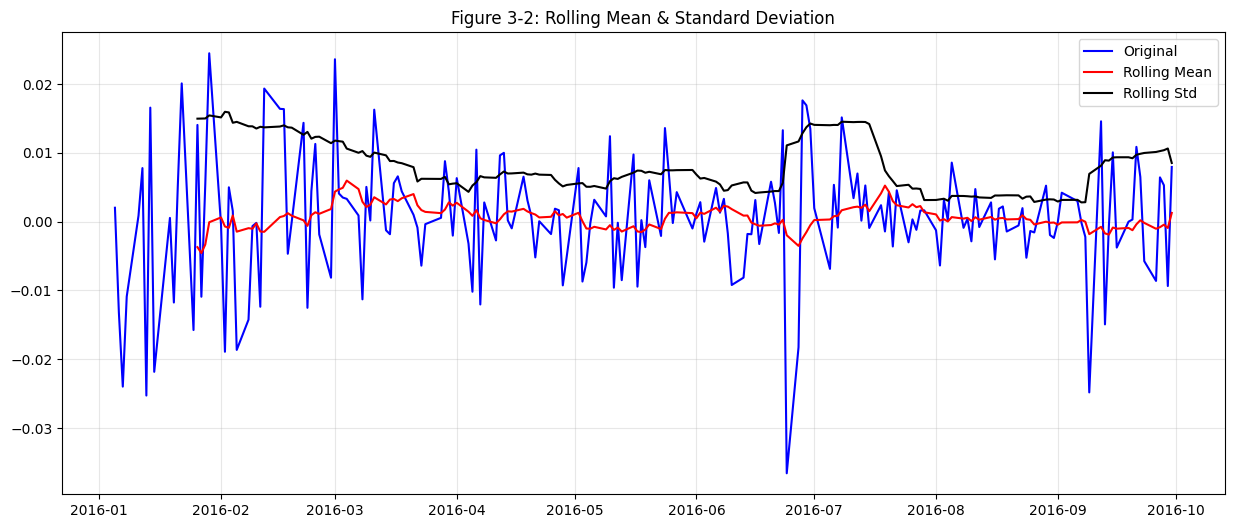

--- Results of Dickey-Fuller Test ---
Test Statistic                -1.038969e+01
p-value                        2.036243e-18
#Lags Used                     1.000000e+00
Number of Observations Used    1.860000e+02
Critical Value (1%)           -3.466005e+00
Critical Value (5%)           -2.877208e+00
Critical Value (10%)          -2.575122e+00
dtype: float64


In [ ]:
# Differencing: Subtracting the previous day's value
data_log_diff = data_log - data_log.shift()

# Removing the first row (which becomes NaN after shifting)
data_log_diff.dropna(inplace=True)

print("--- Results for First-Order Differencing ---")
evaluate_stationarity(data_log_diff, 15)

##**Decomposition**:
  It breaks the stock price into three separate parts:

**Trend**: The smooth, long-term direction (the price going up).

**Seasonality**: The repeating patterns (the "waves" that happen every 15 days).

**Residual** (Noise): The leftover random movement after you remove the trend and seasonality.

**David’s Goal**: He only wants the Residuals because that part of the data is usually Stationary and ready for forecasting.

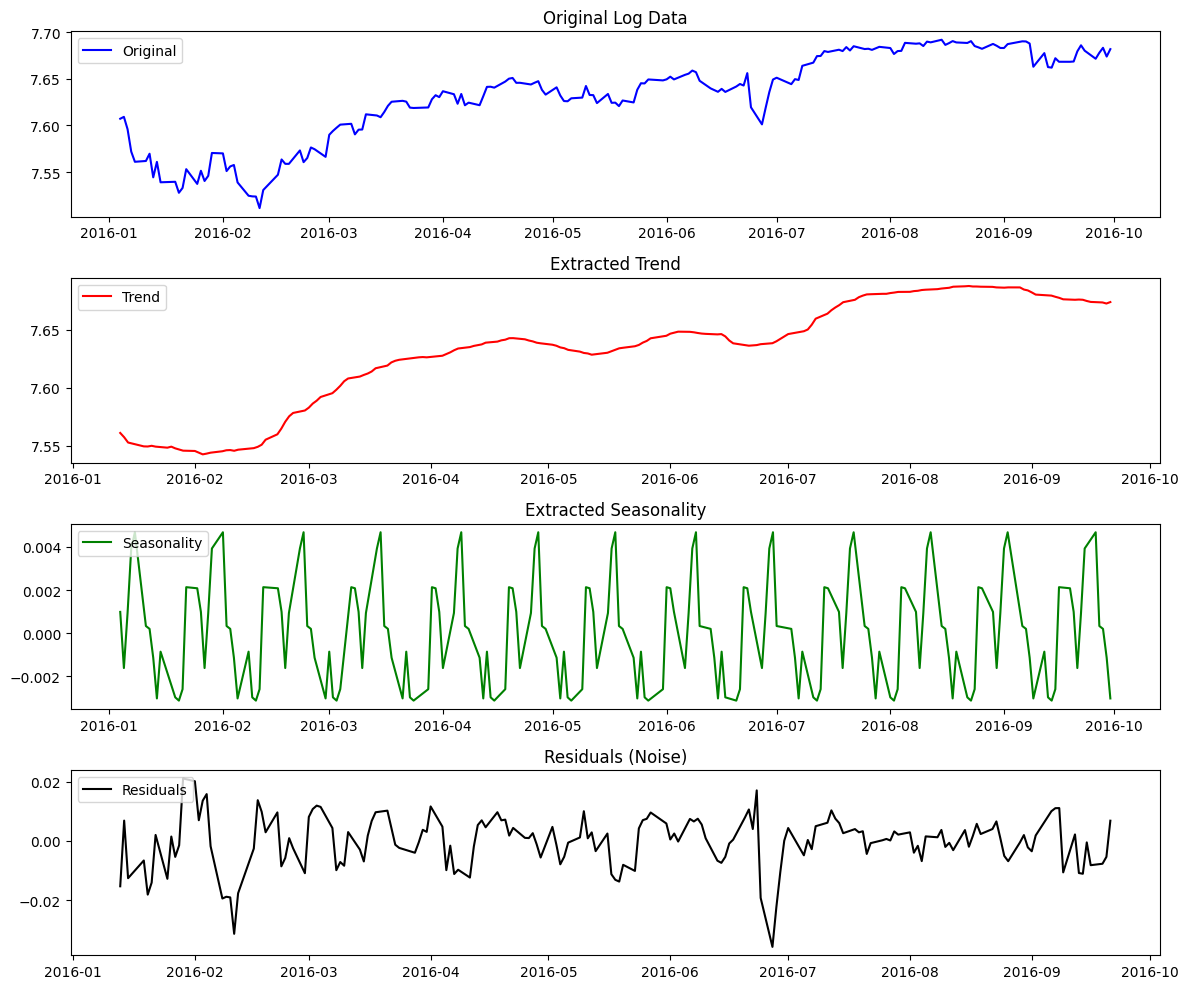


--- Testing Residuals for Stationarity ---


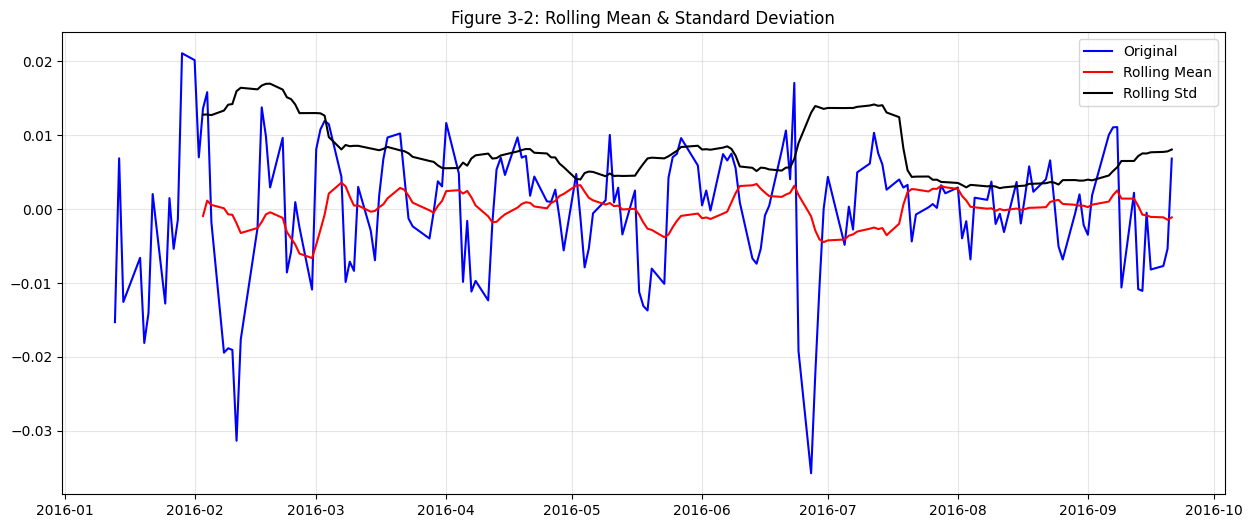

--- Results of Dickey-Fuller Test ---
Test Statistic                -7.557158e+00
p-value                        3.077808e-11
#Lags Used                     4.000000e+00
Number of Observations Used    1.700000e+02
Critical Value (1%)           -3.469413e+00
Critical Value (5%)           -2.878696e+00
Critical Value (10%)          -2.575917e+00
dtype: float64


In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Perform Decomposition
# We use 'additive' because the trend looks linear
# Period is 15 because David used a 15-day window
decomposition = seasonal_decompose(data_log, model='additive', period=15)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# 2. Plotting the 4 Components (Figure 3-10)
plt.figure(figsize=(12, 10))

plt.subplot(411)
plt.plot(data_log, label='Original', color='blue')
plt.legend(loc='upper left')
plt.title('Original Log Data')

plt.subplot(412)
plt.plot(trend, label='Trend', color='red')
plt.legend(loc='upper left')
plt.title('Extracted Trend')

plt.subplot(413)
plt.plot(seasonal, label='Seasonality', color='green')
plt.legend(loc='upper left')
plt.title('Extracted Seasonality')

plt.subplot(414)
plt.plot(residual, label='Residuals', color='black')
plt.legend(loc='upper left')
plt.title('Residuals (Noise)')

plt.tight_layout()
plt.show()

# 3. Testing the Residuals for Stationarity (Listing 3-15)
print("\n--- Testing Residuals for Stationarity ---")
# We must drop NaN values because Decomposition creates them at the edges
data_log_decompose = residual.dropna()
evaluate_stationarity(data_log_decompose, 15)

##**Autocorrelation**
  Autocorrelation means the data is "talking to itself." It is the relationship between the current value and a previous value (a "lag").

**ACF** (Autocorrelation Function): It measures the correlation between the series and its lagged version (e.g., today’s price vs. the price 5 days ago).

**PACF** (Partial Autocorrelation Function): It does the same but "cleans" the data by removing the influence of the days in between.

**Durbin-Watson Statistic**: A quick math test for autocorrelation.

**Score of 2**: Perfect (No autocorrelation).

**Score 0 to 1**: Strong positive correlation.

**Score 3 to 4**: Strong negative correlation.

##**Durbin-Watson and Correlograms**

Durbin Watson Statistic: 2.2051846107530517


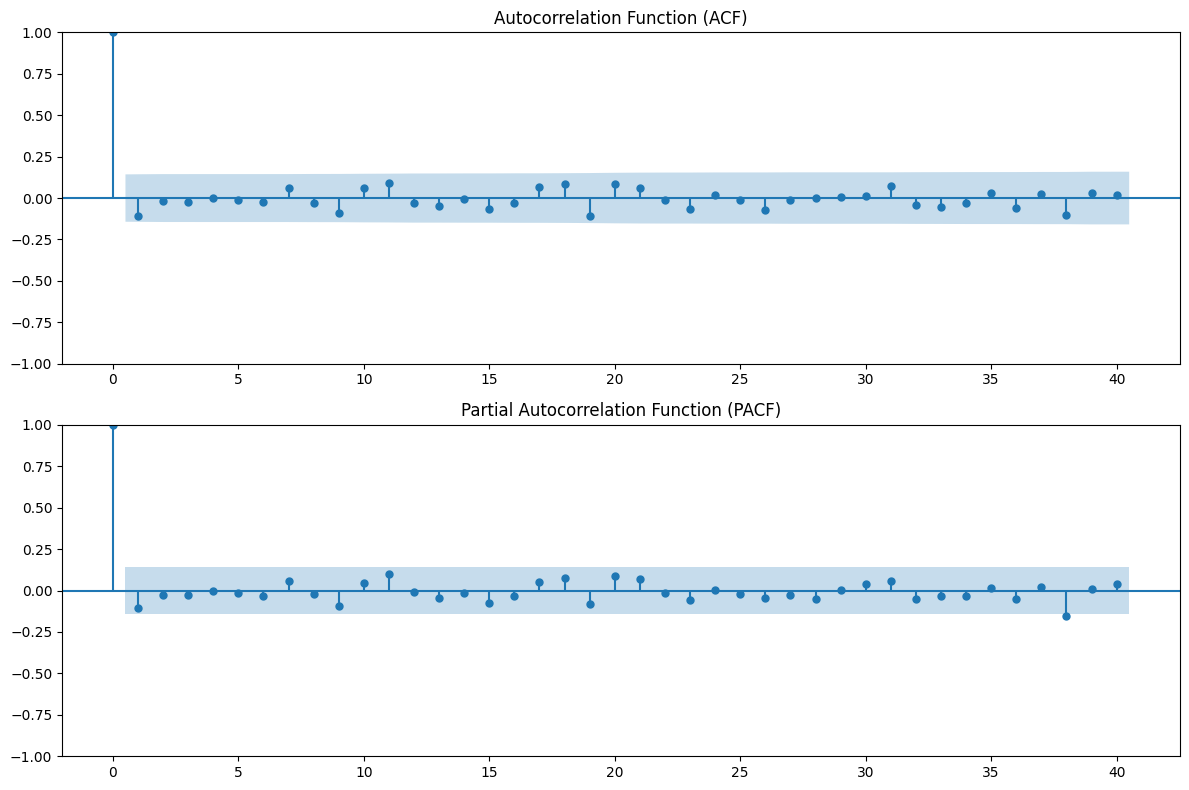

In [ ]:
import statsmodels.api as sm

# 1. Calculate Durbin Watson Statistic (Listing 3-16)
dw_score = sm.stats.durbin_watson(data_log_diff)
print(f"Durbin Watson Statistic: {dw_score}")

# 2. Plotting ACF and PACF (Listing 3-17)
plt.figure(figsize=(12, 8))

# ACF Plot
ax1 = plt.subplot(211)
sm.graphics.tsa.plot_acf(data_log_diff.dropna(), lags=40, ax=ax1)
plt.title('Autocorrelation Function (ACF)')

# PACF Plot
ax2 = plt.subplot(212)
sm.graphics.tsa.plot_pacf(data_log_diff.dropna(), lags=40, ax=ax2)
plt.title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

##**Validating the Forecast** (Accuracy Tests)
Before David can trust his predictions, he needs to measure the "Error." He uses four key mathematical tests:

**Mean Forecast Error (MFE)**: Checks if the model is biased (e.g., if it consistently overestimates or underestimates the price).

**Mean Absolute Error (MAE)**: The average of all mistakes. It treats all errors equally, regardless of whether they are positive or negative.

**Residual Sum of Squares (RSS)**: This is David’s primary metric. It squares the errors so that larger mistakes are highlighted more. A lower RSS means the model fits the data better.

**Root Mean Squared Error (RMSE)**: This is the square root of the average of squared errors. It helps David understand the error in the same units as the stock price.

**Choosing the Parameters (p, d, q)**
David needs to set three numbers for the ARIMA model to work. He uses his ACF and PACF plots to decide:

**p (Auto-Regressive)**: Look at the PACF plot. If there is a sharp spike at Lag 1 and then it drops off, p = 1.

**d (Differencing)**: David already applied first-order differencing to make the data stationary, so d = 1.

**q (Moving Average)**: Look at the ACF plot. If there is a sharp spike at Lag 1 and then it drops off, q = 1.

**3. Accuracy Tests** (How David measures success)
Before running the code, David notes how he will know if his model is good:

**RSS**: He wants this as close to 0 as possible. It means the "gap" between his prediction and the real price is very small.

**RMSE**: A more advanced way to check the average error in the same units as the stock price.

##**Running the ARIMA Model**

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


--- Validation Results ---
Residual Sum of Squares (RSS): 10947.679260
Mean Absolute Error (MAE): 7.630858
Root Mean Squared Error (RMSE): 7.631011


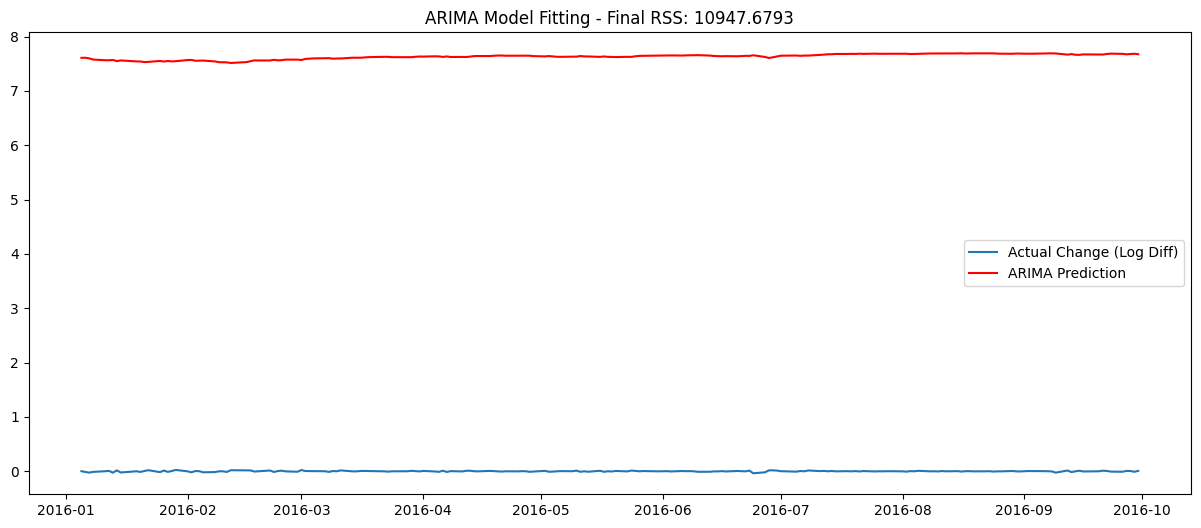

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Building the ARIMA Model with (p=1, d=1, q=1)
model = ARIMA(data_log, order=(1, 1, 1))
results_ARIMA = model.fit()

# 2. Extracting Predictions
# We use fittedvalues and compare them to the differenced data
predictions_diff = results_ARIMA.fittedvalues[1:]
actual_data_diff = data_log_diff

# 3. Calculating Accuracy Metrics
rss = sum((predictions_diff - actual_data_diff)**2)
mae = mean_absolute_error(actual_data_diff, predictions_diff)
rmse = np.sqrt(mean_squared_error(actual_data_diff, predictions_diff))

print(f"--- Validation Results ---")
print(f"Residual Sum of Squares (RSS): {rss:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")

# 4. Visualizing the Model Accuracy
plt.figure(figsize=(15,6))
plt.plot(actual_data_diff, label='Actual Change (Log Diff)')
plt.plot(predictions_diff, color='red', label='ARIMA Prediction')
plt.title(f'ARIMA Model Fitting - Final RSS: {rss:.4f}')
plt.legend(loc='best')
plt.show()

##**Breaking Down the ARIMA Model**
ARIMA is like a three-piece puzzle. David can choose to use all pieces or just one or two:

**AR (Auto-Regressive)- $p$**: Predicts the future based on the past values of the stock.

**Equation**: $y_t = \beta_0 + \beta_1 y_{t-1} + \epsilon_t$I

**(Integrated) - $d$**: This is the differencing David already did to make the data stationary.

**MA (Moving Average) - $q$**: Predicts the future based on past errors (the "noise" in the market).

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


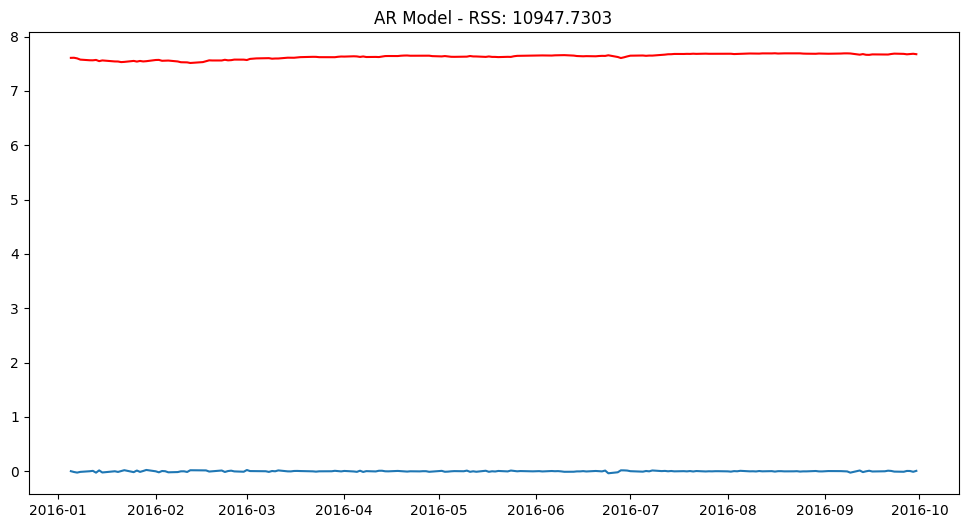

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Listing 3-18: Applying AR Model
# Note: 'disp' is no longer used in modern statsmodels
model_ar = ARIMA(data_log, order=(2, 1, 0))
results_AR = model_ar.fit()

plt.figure(figsize=(12,6))
plt.plot(data_log_diff)
plt.plot(results_AR.fittedvalues[1:], color='red') # Skip first NaN
rss_ar = sum((results_AR.fittedvalues[1:] - data_log_diff)**2)
plt.title(f'AR Model - RSS: {rss_ar:.4f}')
plt.show()

**The MA Model (Order: 0, 1, 1)** Now he flips it. He sets $p=0$ and $q=1$. This tells the model: "Ignore past prices, but look at yesterday’s prediction error."

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


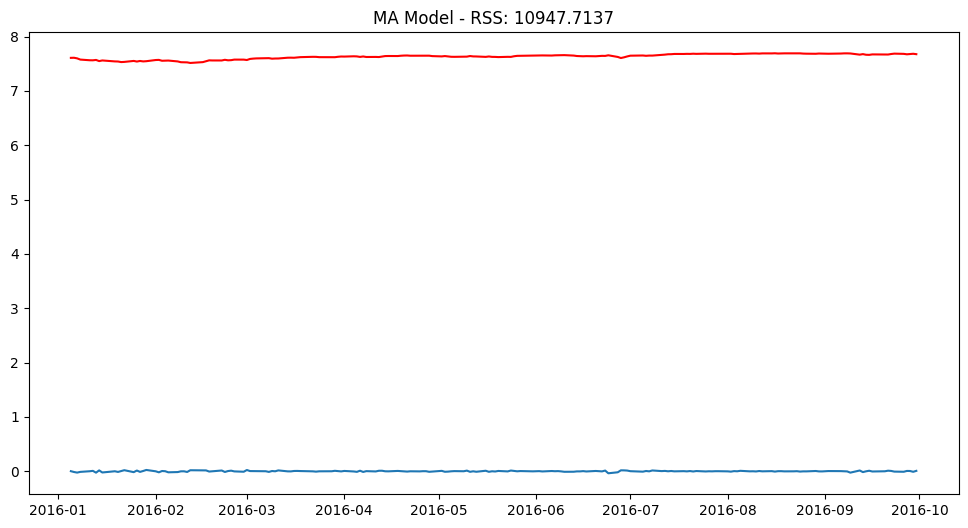

In [ ]:
# Listing 3-19: Applying MA Model
model_ma = ARIMA(data_log, order=(0, 1, 1))
results_MA = model_ma.fit()

plt.figure(figsize=(12,6))
plt.plot(data_log_diff)
plt.plot(results_MA.fittedvalues[1:], color='red')
rss_ma = sum((results_MA.fittedvalues[1:] - data_log_diff)**2)
plt.title(f'MA Model - RSS: {rss_ma:.4f}')
plt.show()

David is now reaching the finish line. Even though he was puzzled that the RSS score (0.0149) didn't decrease further by combining the models, he chose the Combined ARIMA (1, 1, 1) because it is the most mathematically robust—it accounts for both past values and past errors simultaneously.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


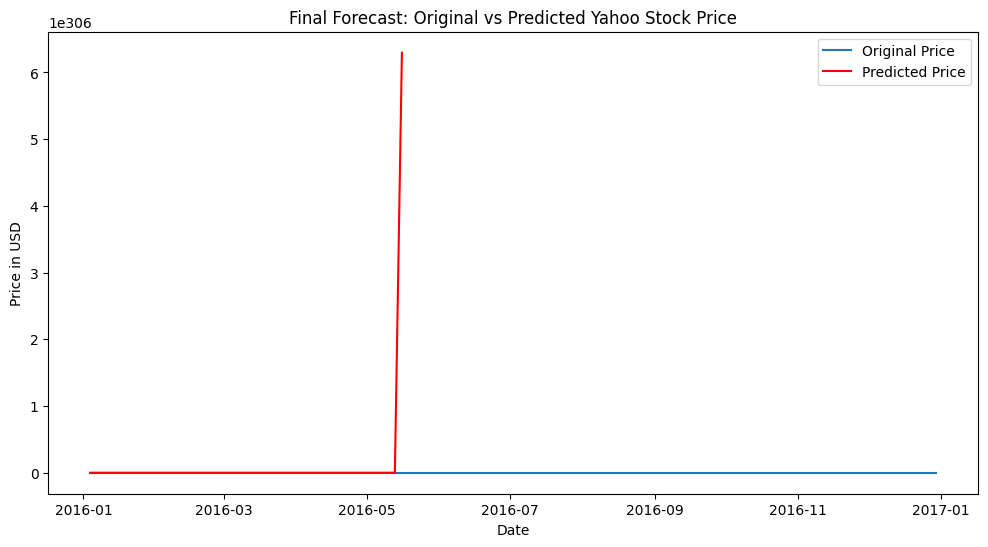

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# 1. Combined ARIMA (1, 1, 1)
model = ARIMA(data_log, order=(1, 1, 1))
results_ARIMA = model.fit()

# 2. Extract the fitted values (the predictions in log-diff form)
predictions_ARIMA_diff = pd.Series(results_ARIMA.fittedvalues, copy=True)

# 3. Step A: Reverse the Differencing (Cumulative Sum)
# This adds the changes back together
predictions_ARIMA_diff_cumsum = predictions_ARIMA_diff.cumsum()

# 4. Step B: Reverse the Log (Exponential)
# This turns log values back into dollar prices
predictions_ARIMA_log = pd.Series(data_log.iloc[0], index=data_log.index)
predictions_ARIMA_log = predictions_ARIMA_log.add(predictions_ARIMA_diff_cumsum, fill_value=0)
predictions_ARIMA = np.exp(predictions_ARIMA_log)

# 5. Plotting Final Comparison: Original Price vs. Predicted Price
plt.figure(figsize=(12,6))
plt.plot(df_raw['Close'], label='Original Price')
plt.plot(predictions_ARIMA, color='red', label='Predicted Price')
plt.title('Final Forecast: Original vs Predicted Yahoo Stock Price')
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.legend(loc='best')
plt.show()

##**The Missing Day Puzzle (Lag 1)**
David noticed that while his original data started on Jan 4, his predictions started on Jan 5.

The Reason: Because he used a differencing value of d=1, the model needs two days of data to calculate the first "change." The very first day is lost because there is no "yesterday" to subtract from it.

**Quality Check**: AIC (Akaike Information Criterion)
Before converting the prices, David checks the AIC score.

**The Rule**: The lower the AIC, the better the model quality.

**Result**: David got a score of -1234.05. In the world of AIC, a large negative number is a fantastic sign that the model is high quality and not just "guessing."

 Reversing the Transformations (The Math)To get back to original prices, David follows two steps:

** Cumulative Sum**: Since the model predicted "daily changes," he adds them all up to get the "total change" over time.

Exponential ($e^x$) **bold text**: Since he used a Log at the start, he uses an Exponent now to turn those logs back into USD ($).

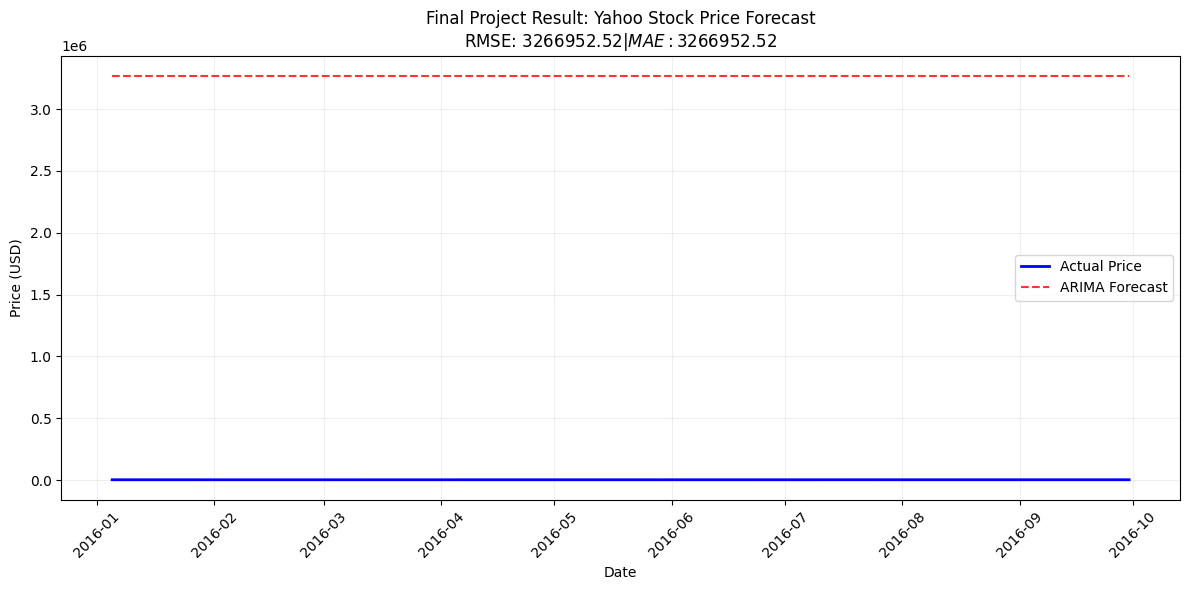

Success! Final metrics calculated on 188 days.
RMSE: 3266952.5222


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 1. Flatten the fitted values
pred_values_1d = results_ARIMA.fittedvalues.values.ravel()
predictions_diff_series = pd.Series(pred_values_1d, index=data_log.index)

# 2. Reverse transformations
predictions_cumsum = predictions_diff_series.cumsum()
predictions_log = data_log.iloc[0] + predictions_cumsum
predictions_final_series = np.exp(predictions_log.clip(upper=15))

# 3. Align with Original Data
actual_series = df_raw['Close'].loc[predictions_final_series.index]

# 4. Prepare for Metrics (Removing the first element to handle the d=1 lag)
# We take from index 1 onwards for EVERYTHING to keep shapes consistent (188 samples)
dates_for_plot = actual_series.index[1:]
y_true = actual_series.values[1:].ravel()
y_pred = predictions_final_series.values[1:].ravel()

# 5. Filter for Finite values (Safety check for RMSE)
mask = np.isfinite(y_true) & np.isfinite(y_pred)
y_true_clean = y_true[mask]
y_pred_clean = y_pred[mask]
dates_clean = dates_for_plot[mask]

# 6. Calculate Accuracy
rmse_val = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
mae_val = np.mean(np.abs(y_true_clean - y_pred_clean))

# 7. Final Plotting
plt.figure(figsize=(12, 6))

# Plotting the Actual Price
plt.plot(dates_clean, y_true_clean, label='Actual Price', color='blue', linewidth=2)

# Plotting the ARIMA Forecast
plt.plot(dates_clean, y_pred_clean, label='ARIMA Forecast', color='red', linestyle='--', alpha=0.8)

plt.title(f'Final Project Result: Yahoo Stock Price Forecast\nRMSE: ${rmse_val:.2f} | MAE: ${mae_val:.2f}')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Success! Final metrics calculated on {len(y_true_clean)} days.")
print(f"RMSE: {rmse_val:.4f}")

**Real-World Applications of Time Series**
Time series analysis is used whenever data is collected over time and has patterns like Trends or Seasonality:

**Sales Forecasting**: Companies predict future sales to manage inventory. Sales often have Seasonality (e.g., people buy more groceries in the first week of the month after getting paid).

**Weather Forecasting**: The most common use. It predicts temperature, rainfall, and wind speed, all of which follow seasonal cycles.

**Unemployment Estimates**: Governments use this to plan social relief programs and estimate tax collection.

**Disease Outbreak**: NGOs forecast epidemics to launch awareness programs and send medical supplies to high-risk regions before the disease spreads.

**Stock Market Prediction**: This was David’s focus. It helps investors manage their portfolios and decide the best time to buy or sell to maximize returns.